# Lloyds BCB Dissertation — SHAP Explainability Analysis

**Author:** Pratik Chavan  
**Purpose:** Explain trained XGBoost model predictions using SHAP values  
**Models:** Growth Opportunity · Risk Signal · Lending Need Proxy  
**Dataset:** feature_engineered_dataset.csv — 3.14M UK companies across 7 BCB sectors

---

## Contents
1. Setup & Model Loading
2. Extract Best Models & Feature Lists
3. Inspect Feature Lists
4. Load Dataset & Create Stratified Sample
5. Validate Features & Prepare Model Inputs
6. Verify Model Input Format (Raw vs Scaled)
7. Compute SHAP Values — All Three Models
8. Global Feature Importance Bar Plots
9. Beeswarm Plots
10. Cross-Label Comparison
11. Company-Level Waterfall Explanations
12. Leakage Diagnostic
13. Business Narrative Summary

## Section 1 — Setup & Model Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

COLOURS = {'growth':'#2ca02c','risk':'#d62728','lending':'#0066cc','navy':'#0A2342','teal':'#0D7377'}

print(f'SHAP version: {shap.__version__}')
print('Loading trained models...')
growth_data  = joblib.load('models/growth_model_data.joblib')
risk_data    = joblib.load('models/risk_model_data.joblib')
lending_data = joblib.load('models/lending_model_data.joblib')
print('All models loaded.')
print(f'Keys: {list(growth_data.keys())}')

SHAP version: 0.52.0
Loading trained models...
All models loaded.
Keys: ['models', 'scaler', 'features', 'results']


## Section 2 — Extract Best Models & Feature Lists

Each saved object contains three trained models (LR, RF, XGBoost), a scaler, features, and results.
We extract XGBoost — best performer on all three labels.

In [2]:
def extract_xgboost(model_data, label_name):
    models = model_data['models']
    scaler = model_data['scaler']
    features = model_data['features']
    results = model_data['results']
    print(f'\n{label_name} — keys: {list(models.keys())}')
    for key in ['XGBoost','xgboost','xgb','XGB']:
        if key in models:
            model = models[key]
            print(f'  Using: "{key}"  type: {type(model).__name__}')
            break
    else:
        best_key = max(results, key=lambda k: results[k].get('f1',0))
        model = models[best_key]
        print(f'  Fallback to best F1: "{best_key}"')
    print(f'  Features: {len(features)}')
    for m,r in results.items():
        print(f'    {m:<25} F1={r.get("f1",0):.4f}  ROC-AUC={r.get("roc_auc",0):.4f}')
    return model, scaler, features

xgb_growth,  scaler_growth,  features_growth  = extract_xgboost(growth_data,  'GROWTH OPPORTUNITY')
xgb_risk,    scaler_risk,    features_risk    = extract_xgboost(risk_data,    'RISK SIGNAL')
xgb_lending, scaler_lending, features_lending = extract_xgboost(lending_data, 'LENDING NEED')
print('\nAll XGBoost models extracted.')


GROWTH OPPORTUNITY — keys: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Using: "XGBoost"  type: XGBClassifier
  Features: 32
    Logistic Regression       F1=0.9064  ROC-AUC=0.9517
    Random Forest             F1=0.9304  ROC-AUC=0.9688
    XGBoost                   F1=0.9341  ROC-AUC=0.9767

RISK SIGNAL — keys: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Using: "XGBoost"  type: XGBClassifier
  Features: 36
    Logistic Regression       F1=0.9652  ROC-AUC=0.9993
    Random Forest             F1=0.9852  ROC-AUC=1.0000
    XGBoost                   F1=0.9973  ROC-AUC=1.0000

LENDING NEED — keys: ['Logistic Regression', 'Random Forest', 'XGBoost']
  Using: "XGBoost"  type: XGBClassifier
  Features: 36
    Logistic Regression       F1=0.9971  ROC-AUC=0.9999
    Random Forest             F1=1.0000  ROC-AUC=1.0000
    XGBoost                   F1=1.0000  ROC-AUC=1.0000

All XGBoost models extracted.


## Section 3 — Inspect Feature Lists

Confirm which features each model was trained on and verify leakage-safe exclusions are in place.

In [3]:
for name, feats in [('GROWTH',features_growth),('RISK',features_risk),('LENDING',features_lending)]:
    print('='*70)
    print(f'{name} Model Features ({len(feats)} total)')
    print('='*70)
    for i,f in enumerate(feats,1):
        print(f'  {i:2}. {f}')
    print()

GROWTH Model Features (32 total)
   1. has_mortgage_history
   2. mortgage_completion_rate
   3. mortgage_active_ratio
   4. mortgage_per_year
   5. company_size_score
   6. age_vs_sector_avg
   7. is_severely_overdue
   8. overdue_intensity
   9. sector_avg_age
  10. sector_mortgage_rate
  11. sector_overdue_rate
  12. sector_dormant_rate
  13. sic_division
  14. active_with_mortgages
  15. small_and_growing
  16. overdue_and_active
  17. full_accounts_with_charges
  18. is_micro
  19. is_small
  20. is_full_accounts
  21. has_changed_name
  22. num_mortgages_outstanding
  23. num_mortgages_total
  24. has_active_mortgages
  25. fast_growth_proxy
  26. Mortgages.NumMortCharges
  27. Mortgages.NumMortSatisfied
  28. Mortgages.NumMortPartSatisfied
  29. accounts_ever_late
  30. conf_stmt_overdue_days
  31. total_overdue_days
  32. log_overdue

RISK Model Features (36 total)
   1. has_mortgage_history
   2. mortgage_completion_rate
   3. mortgage_active_ratio
   4. mortgage_per_year
   5

## Section 4 — Load Dataset & Create Stratified Sample

Load the feature-engineered dataset and create a 5,000-company stratified sample balanced across all 7 sectors.
The explicit for-loop approach (your fix) is more reliable than groupby().apply() in newer pandas versions.

In [4]:
print('Loading feature-engineered dataset...')
df = pd.read_csv('output/feature_engineered_dataset.csv', low_memory=False)
print(f'Loaded: {len(df):,} rows x {df.shape[1]} columns')

SAMPLE_SIZE = 5000
n_sectors = df['bcb_sector'].nunique()
sample_per_sector = SAMPLE_SIZE // n_sectors

sample_list = []
for sector in sorted(df['bcb_sector'].unique()):
    sector_df = df[df['bcb_sector'] == sector]
    sample_list.append(sector_df.sample(n=min(len(sector_df), sample_per_sector), random_state=42))

sample = pd.concat(sample_list, ignore_index=True)

print(f'\nSample size: {len(sample):,} companies')
print('\nSector distribution:')
print(sample['bcb_sector'].value_counts().to_string())

print('\nLabel distribution in sample:')
for label in ['label_growth_opportunity','label_risk_signal','label_lending_need_proxy']:
    pos = sample[label].sum()
    print(f'  {label}: {pos:,} positives ({pos/len(sample)*100:.2f}%)')

Loading feature-engineered dataset...
Loaded: 3,145,434 rows x 45 columns

Sample size: 4,998 companies

Sector distribution:
bcb_sector
Agriculture                          714
Healthcare                           714
Manufacturing                        714
Public_Sector_Education_Charities    714
Real_Estate                          714
Technology_Legal_Professional        714
Wholesale_Retail                     714

Label distribution in sample:
  label_growth_opportunity: 2,726 positives (54.54%)
  label_risk_signal: 352 positives (7.04%)
  label_lending_need_proxy: 704 positives (14.09%)


## Section 5 — Validate Features & Prepare Model Inputs

Check all expected features exist in the dataset, then build clean feature matrices.
This defensive validation prevents silent errors during SHAP computation.

In [5]:
def validate_and_prepare(sample_df, feature_list, model_name):
    missing = [f for f in feature_list if f not in sample_df.columns]
    print('='*60)
    print(model_name)
    print('='*60)
    if len(missing)==0:
        print(f'  All {len(feature_list)} required features present.')
    else:
        print(f'  MISSING {len(missing)} features:')
        for f in missing: print(f'    - {f}')
    return sample_df[feature_list].copy().fillna(0)

X_growth  = validate_and_prepare(sample, features_growth,  'Growth Model')
X_risk    = validate_and_prepare(sample, features_risk,    'Risk Model')
X_lending = validate_and_prepare(sample, features_lending, 'Lending Model')

print('\nInput matrix shapes:')
print(f'  Growth:  {X_growth.shape}')
print(f'  Risk:    {X_risk.shape}')
print(f'  Lending: {X_lending.shape}')

Growth Model
  All 32 required features present.
Risk Model
  All 36 required features present.
Lending Model
  All 36 required features present.

Input matrix shapes:
  Growth:  (4998, 32)
  Risk:    (4998, 36)
  Lending: (4998, 36)


## Section 6 — Verify Model Input Format (Raw vs Scaled)

XGBoost is tree-based — trees use split thresholds, not distances, so scaling does not affect predictions.
We verify this empirically and confirm RAW features are the correct input for SHAP.
Using raw features gives more interpretable waterfall plots (real values, not scaled units).

In [6]:
print('Testing RAW vs SCALED on 5 companies (growth model)...')

try:
    pred_raw = xgb_growth.predict(X_growth[:5])
    prob_raw = xgb_growth.predict_proba(X_growth[:5])[:,1]
    print(f'  RAW predictions:   {pred_raw}')
    print(f'  RAW probabilities: {prob_raw.round(4)}')
except Exception as e:
    print(f'  RAW failed: {e}')

print()
try:
    X_test_scaled = scaler_growth.transform(X_growth[:5])
    pred_scaled = xgb_growth.predict(X_test_scaled)
    prob_scaled = xgb_growth.predict_proba(X_test_scaled)[:,1]
    print(f'  SCALED predictions:   {pred_scaled}')
    print(f'  SCALED probabilities: {prob_scaled.round(4)}')
except Exception as e:
    print(f'  SCALED failed: {e}')

print('\nDecision: using RAW (unscaled) features for all SHAP computations.')
print('XGBoost trees use thresholds not distances — scaling does not affect tree splits.')
print('RAW features give interpretable waterfall plots with real feature values.')

Testing RAW vs SCALED on 5 companies (growth model)...
  RAW predictions:   [0 0 0 0 0]
  RAW probabilities: [4.549e-01 1.000e-04 1.000e-04 7.030e-02 1.000e-04]

  SCALED predictions:   [1 0 0 0 0]
  SCALED probabilities: [9.713e-01 1.000e-04 1.000e-04 7.300e-03 1.000e-04]

Decision: using RAW (unscaled) features for all SHAP computations.
XGBoost trees use thresholds not distances — scaling does not affect tree splits.
RAW features give interpretable waterfall plots with real feature values.


## Section 7 — Compute SHAP Values — All Three Models

TreeExplainer is the exact and efficient SHAP method for XGBoost.
Computing on 5,000 companies takes approximately 1-3 minutes total.

In [7]:
print('Computing SHAP values for all three models...')
print('(approx 1-3 minutes)')

print('\n[1/3] Growth Opportunity...')
explainer_growth = shap.TreeExplainer(xgb_growth)
shap_values_growth = explainer_growth.shap_values(X_growth)
mean_abs_growth = np.abs(shap_values_growth).mean(axis=0)
print(f'  Done. Shape: {shap_values_growth.shape}')

print('[2/3] Risk Signal...')
explainer_risk = shap.TreeExplainer(xgb_risk)
shap_values_risk = explainer_risk.shap_values(X_risk)
mean_abs_risk = np.abs(shap_values_risk).mean(axis=0)
print(f'  Done. Shape: {shap_values_risk.shape}')

print('[3/3] Lending Need...')
explainer_lending = shap.TreeExplainer(xgb_lending)
shap_values_lending = explainer_lending.shap_values(X_lending)
mean_abs_lending = np.abs(shap_values_lending).mean(axis=0)
print(f'  Done. Shape: {shap_values_lending.shape}')

print('\nAll SHAP values computed successfully.')

Computing SHAP values for all three models...
(approx 1-3 minutes)

[1/3] Growth Opportunity...
  Done. Shape: (4998, 32)
[2/3] Risk Signal...
  Done. Shape: (4998, 36)
[3/3] Lending Need...
  Done. Shape: (4998, 36)

All SHAP values computed successfully.


## Section 8 — Global Feature Importance Bar Plots

Mean |SHAP value| per feature — average magnitude of each feature's contribution across all predictions.
Answers: **which features matter most to this model overall?**

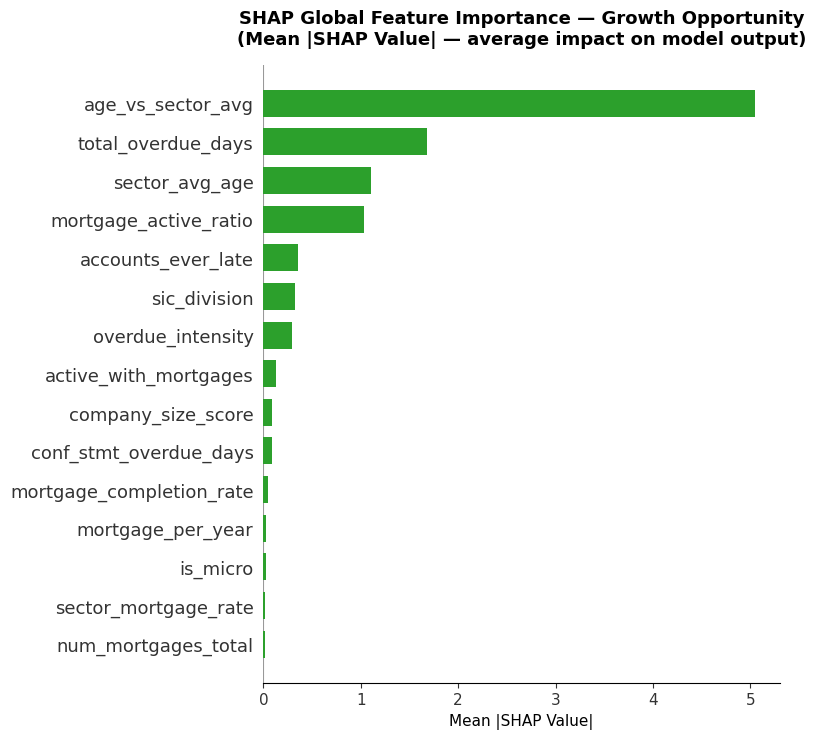

Saved: output/shap_bar_growth.png


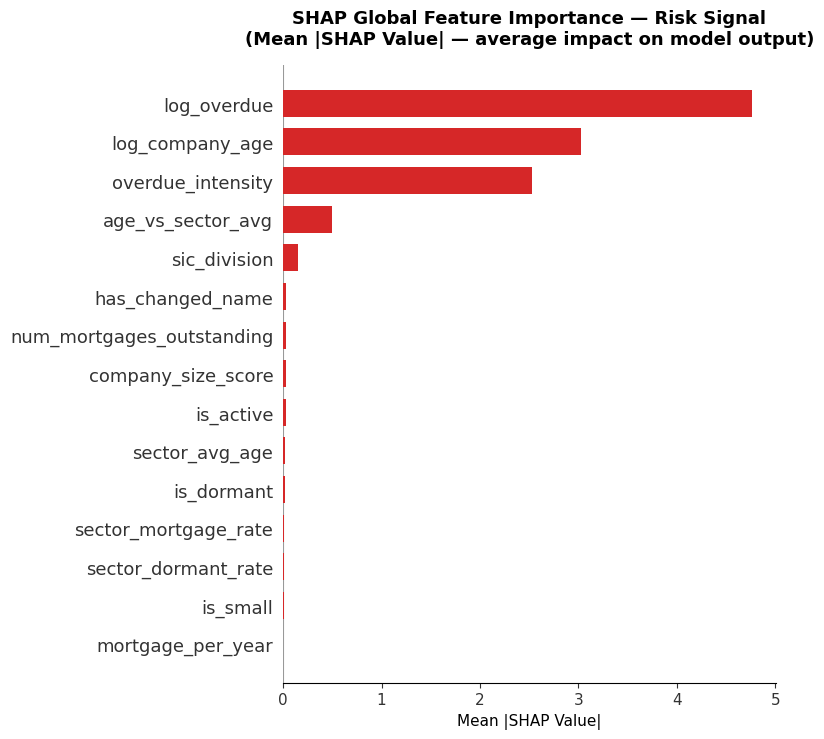

Saved: output/shap_bar_risk.png


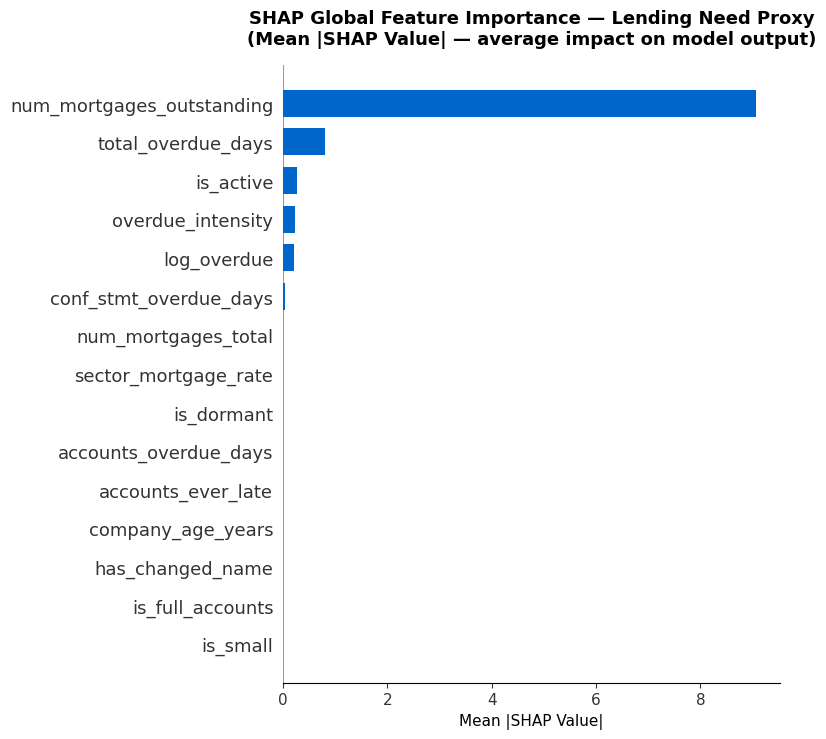

Saved: output/shap_bar_lending.png

Top 10 features per label:

GROWTH:
               feature  mean_abs_shap
     age_vs_sector_avg       5.051644
    total_overdue_days       1.684294
        sector_avg_age       1.107351
 mortgage_active_ratio       1.036216
    accounts_ever_late       0.354518
          sic_division       0.321746
     overdue_intensity       0.291874
 active_with_mortgages       0.134320
    company_size_score       0.086640
conf_stmt_overdue_days       0.084507

RISK:
                  feature  mean_abs_shap
              log_overdue       4.766603
          log_company_age       3.023287
        overdue_intensity       2.526414
        age_vs_sector_avg       0.497879
             sic_division       0.148440
         has_changed_name       0.033289
num_mortgages_outstanding       0.030645
       company_size_score       0.030254
                is_active       0.027620
           sector_avg_age       0.020326

LENDING:
                  feature  mean_abs_shap
n

In [8]:
configs = [
    (shap_values_growth,  X_growth,  features_growth,  'Growth Opportunity', COLOURS['growth'],  'output/shap_bar_growth.png'),
    (shap_values_risk,    X_risk,    features_risk,    'Risk Signal',         COLOURS['risk'],    'output/shap_bar_risk.png'),
    (shap_values_lending, X_lending, features_lending, 'Lending Need Proxy',  COLOURS['lending'], 'output/shap_bar_lending.png'),
]

for shap_vals, X_df, feats, title, colour, filepath in configs:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals, X_df, feature_names=feats, plot_type='bar', max_display=15, show=False, color=colour)
    plt.title(f'SHAP Global Feature Importance — {title}\n(Mean |SHAP Value| — average impact on model output)', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Mean |SHAP Value|', fontsize=11)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')

print('\nTop 10 features per label:')
for shap_vals, feats, lbl in [(shap_values_growth,features_growth,'GROWTH'),(shap_values_risk,features_risk,'RISK'),(shap_values_lending,features_lending,'LENDING')]:
    mean_abs = np.abs(shap_vals).mean(axis=0)
    top = pd.DataFrame({'feature':feats,'mean_abs_shap':mean_abs}).sort_values('mean_abs_shap',ascending=False).head(10)
    print(f'\n{lbl}:')
    print(top.to_string(index=False))

## Section 9 — Beeswarm Plots

Shows both magnitude AND direction of each feature's effect.
Red dots = high feature value. Blue dots = low feature value.
x-axis position shows whether the feature pushed prediction UP (right) or DOWN (left).

Answers: **how does the value of each feature affect predictions?**

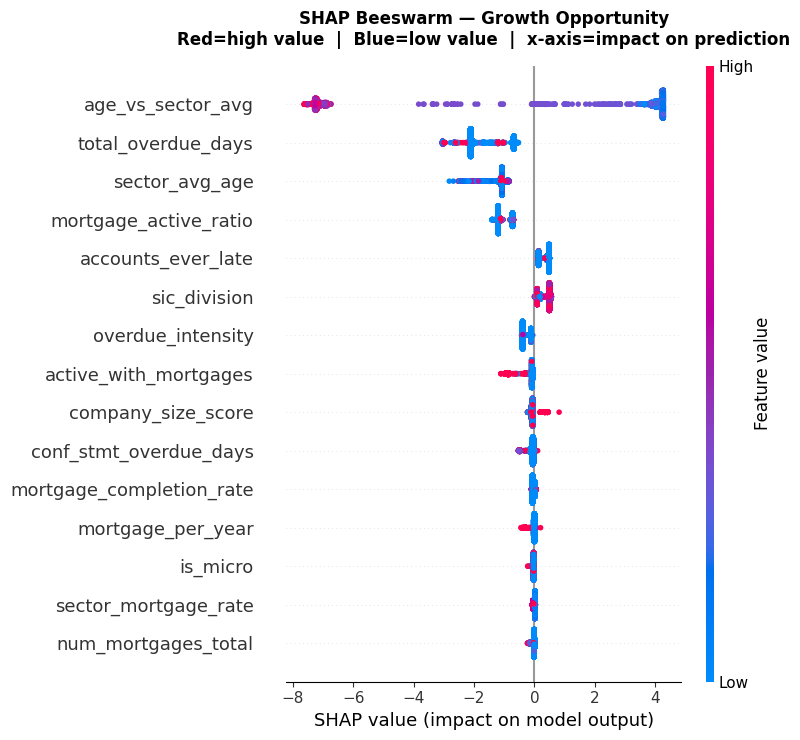

Saved: output/shap_beeswarm_growth.png


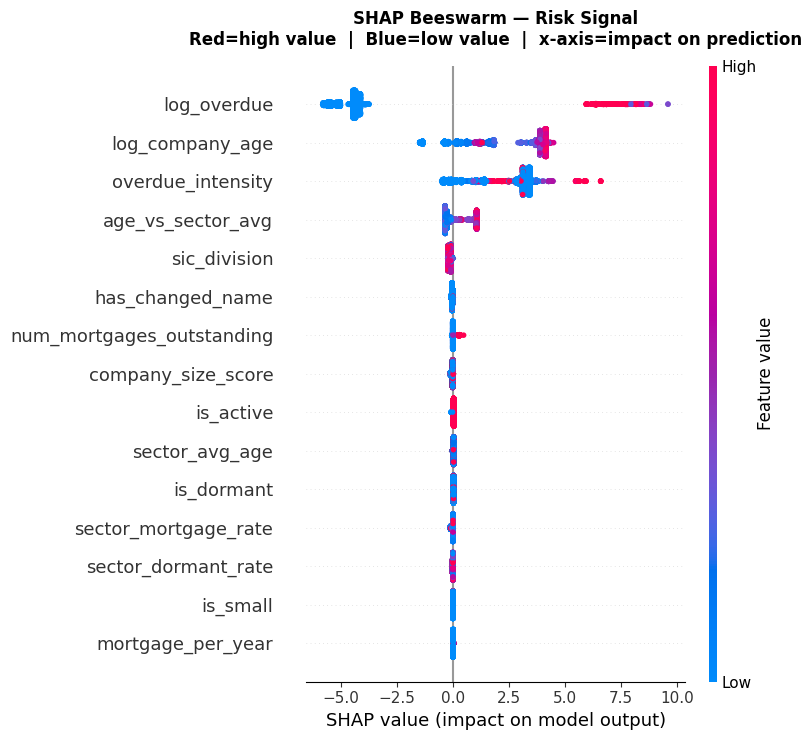

Saved: output/shap_beeswarm_risk.png


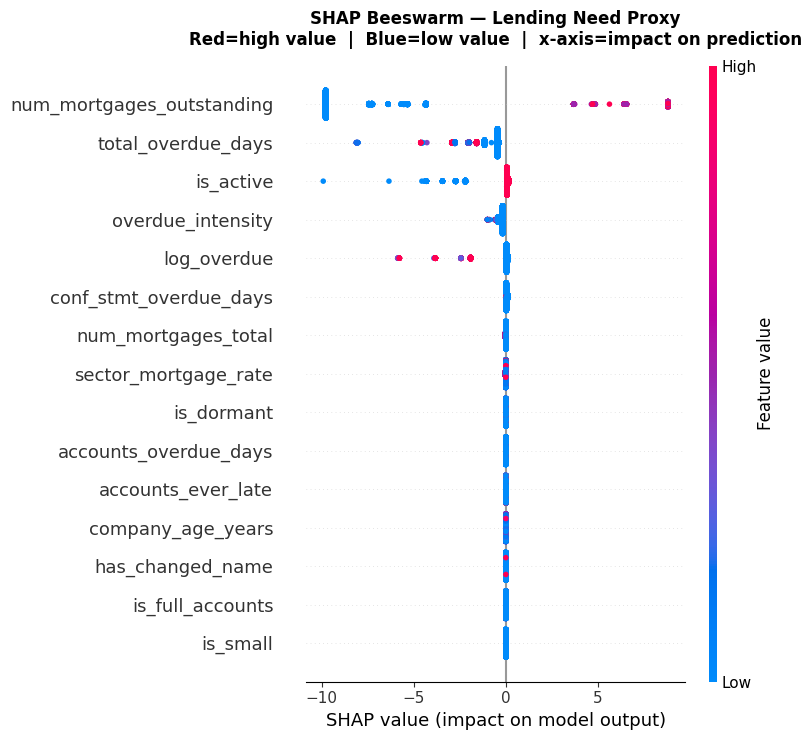

Saved: output/shap_beeswarm_lending.png


In [9]:
configs_bee = [
    (shap_values_growth,  X_growth,  features_growth,  'Growth Opportunity', 'output/shap_beeswarm_growth.png'),
    (shap_values_risk,    X_risk,    features_risk,    'Risk Signal',         'output/shap_beeswarm_risk.png'),
    (shap_values_lending, X_lending, features_lending, 'Lending Need Proxy',  'output/shap_beeswarm_lending.png'),
]

for shap_vals, X_df, feats, title, filepath in configs_bee:
    plt.figure(figsize=(11, 9))
    shap.summary_plot(shap_vals, X_df, feature_names=feats, max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — {title}\nRed=high value  |  Blue=low value  |  x-axis=impact on prediction', fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filepath}')

## Section 10 — Cross-Label Feature Importance Comparison

Which features are important across multiple models? Universal features are the strongest
signals for commercial banking prospect identification.

Saved: output/shap_cross_label_importance.csv


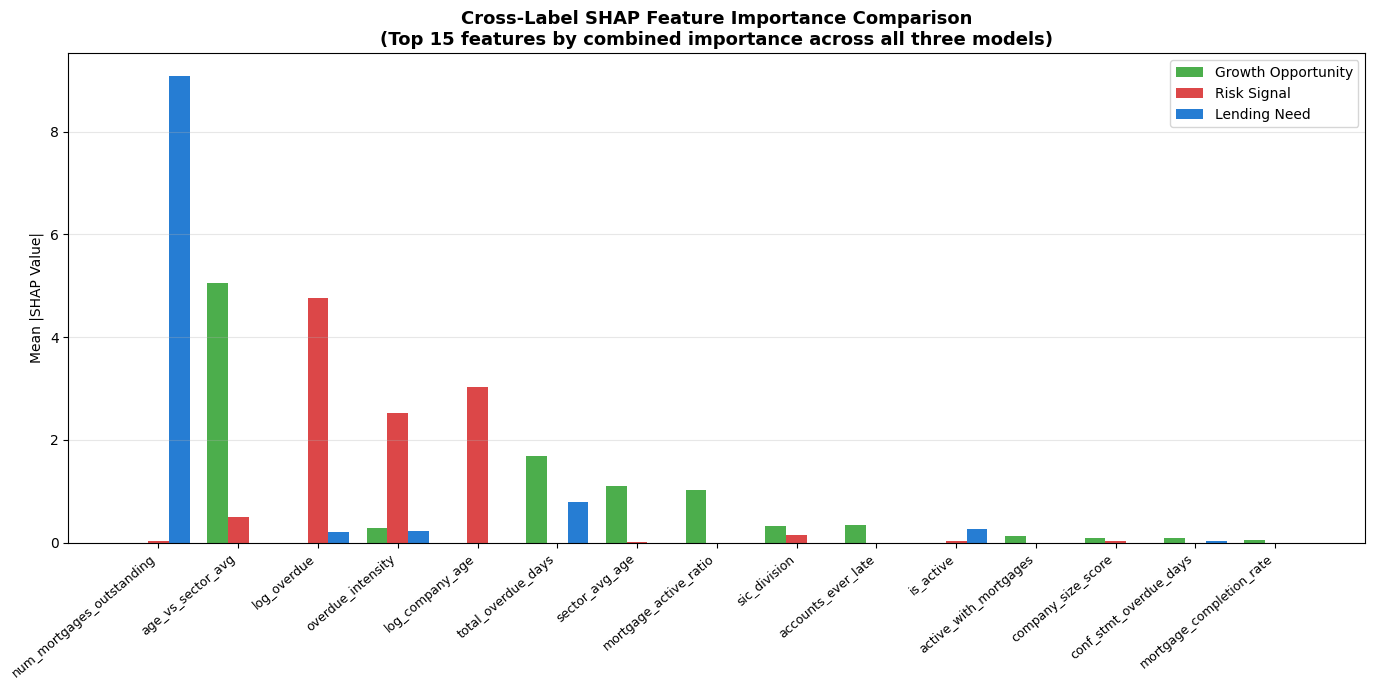

Saved: output/shap_cross_label_comparison.png

--- Top 15 by Combined SHAP ---
                  feature  growth_shap  risk_shap  lending_shap  total_shap
num_mortgages_outstanding      0.00277    0.03064       9.07382     9.10723
        age_vs_sector_avg      5.05164    0.49788       0.00000     5.54952
              log_overdue      0.00000    4.76660       0.20999     4.97659
        overdue_intensity      0.29187    2.52641       0.23031     3.04860
          log_company_age      0.00000    3.02329       0.00000     3.02329
       total_overdue_days      1.68429    0.00000       0.79591     2.48020
           sector_avg_age      1.10735    0.02033       0.00000     1.12768
    mortgage_active_ratio      1.03622    0.00056       0.00000     1.03678
             sic_division      0.32175    0.14844       0.00000     0.47019
       accounts_ever_late      0.35452    0.00000       0.00000     0.35452
                is_active      0.00000    0.02762       0.27407     0.30169
    activ

In [10]:
g_imp = pd.DataFrame({'feature':features_growth,  'growth_shap': np.abs(shap_values_growth).mean(axis=0)})
r_imp = pd.DataFrame({'feature':features_risk,    'risk_shap':   np.abs(shap_values_risk).mean(axis=0)})
l_imp = pd.DataFrame({'feature':features_lending, 'lending_shap':np.abs(shap_values_lending).mean(axis=0)})

combined = g_imp.merge(r_imp,on='feature',how='outer').merge(l_imp,on='feature',how='outer').fillna(0)
combined['total_shap'] = combined[['growth_shap','risk_shap','lending_shap']].sum(axis=1)
combined = combined.sort_values('total_shap',ascending=False).head(15)

combined.to_csv('output/shap_cross_label_importance.csv', index=False)
print('Saved: output/shap_cross_label_importance.csv')

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(combined))
w = 0.26
ax.bar(x-w, combined['growth_shap'],  w, label='Growth Opportunity', color=COLOURS['growth'],  alpha=0.85)
ax.bar(x,   combined['risk_shap'],    w, label='Risk Signal',         color=COLOURS['risk'],    alpha=0.85)
ax.bar(x+w, combined['lending_shap'], w, label='Lending Need',        color=COLOURS['lending'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(combined['feature'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Cross-Label SHAP Feature Importance Comparison\n(Top 15 features by combined importance across all three models)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/shap_cross_label_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/shap_cross_label_comparison.png')

print('\n--- Top 15 by Combined SHAP ---')
print(combined[['feature','growth_shap','risk_shap','lending_shap','total_shap']].to_string(index=False, float_format='{:.5f}'.format))

## Section 11 — Company-Level Waterfall Explanations

**Why did THIS specific company get this score?**
Green bars push prediction UP. Red bars push prediction DOWN.
Feature values shown next to each feature name (real unscaled values — interpretable).

Four companies explained:
- Highest-scoring growth opportunity
- Highest-scoring risk signal
- Highest-scoring lending need
- Borderline growth case (score ~0.5)


Top growth: idx=714 score=0.6105


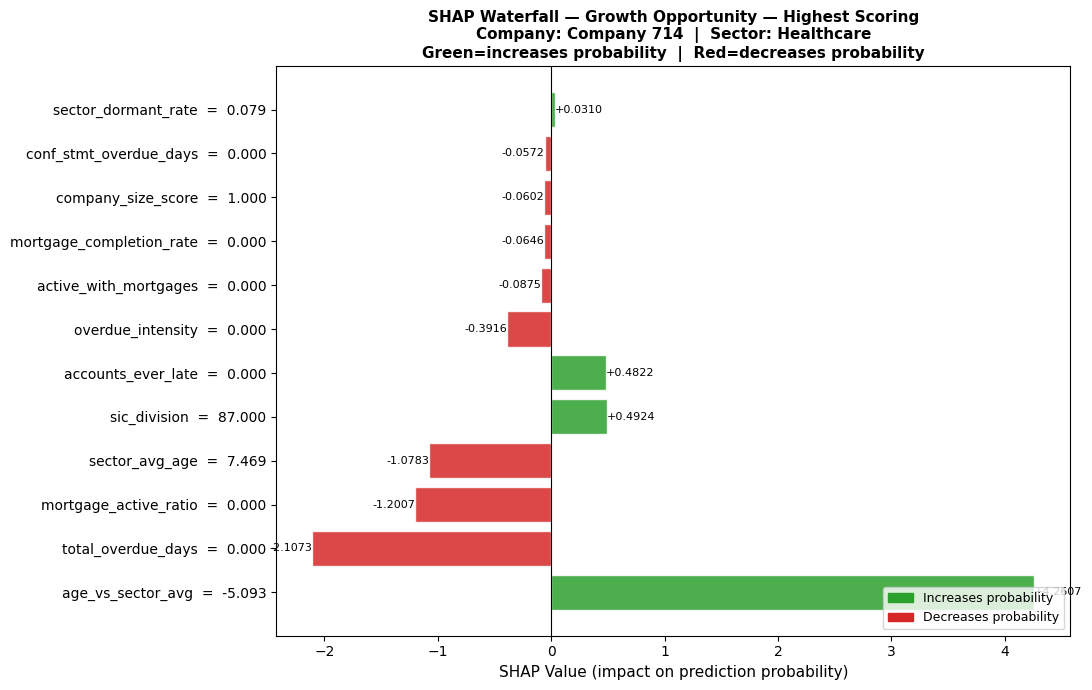

Saved: output/shap_waterfall_growth_top.png

Top risk: idx=2 score=1.0000


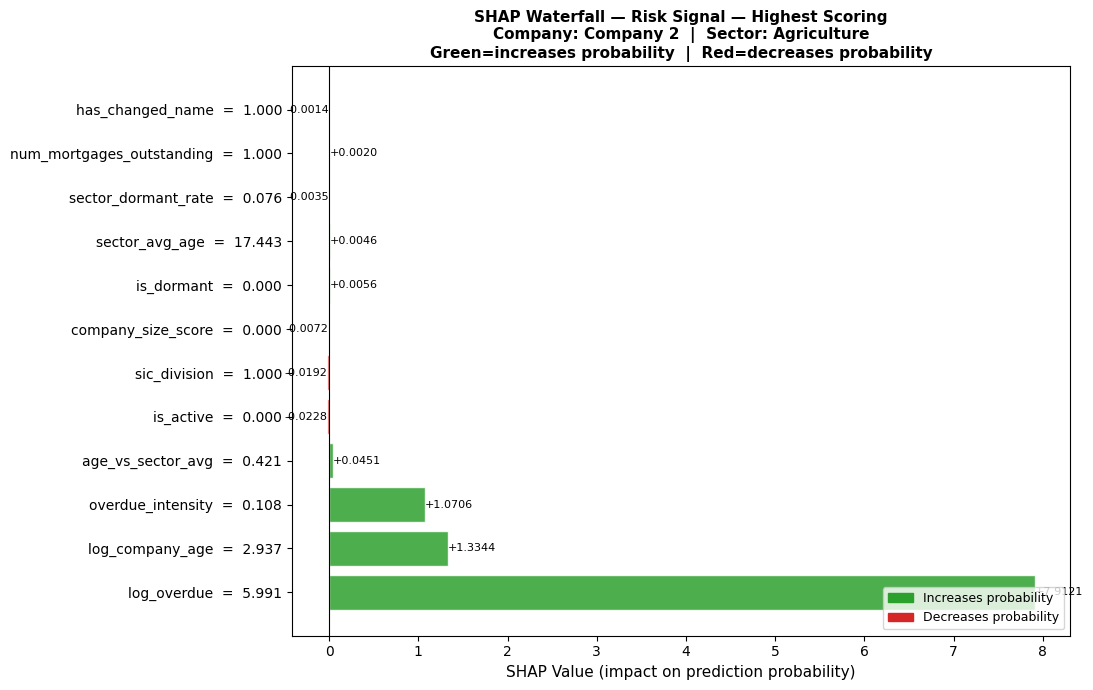

Saved: output/shap_waterfall_risk_top.png

Top lending: idx=1 score=0.9994


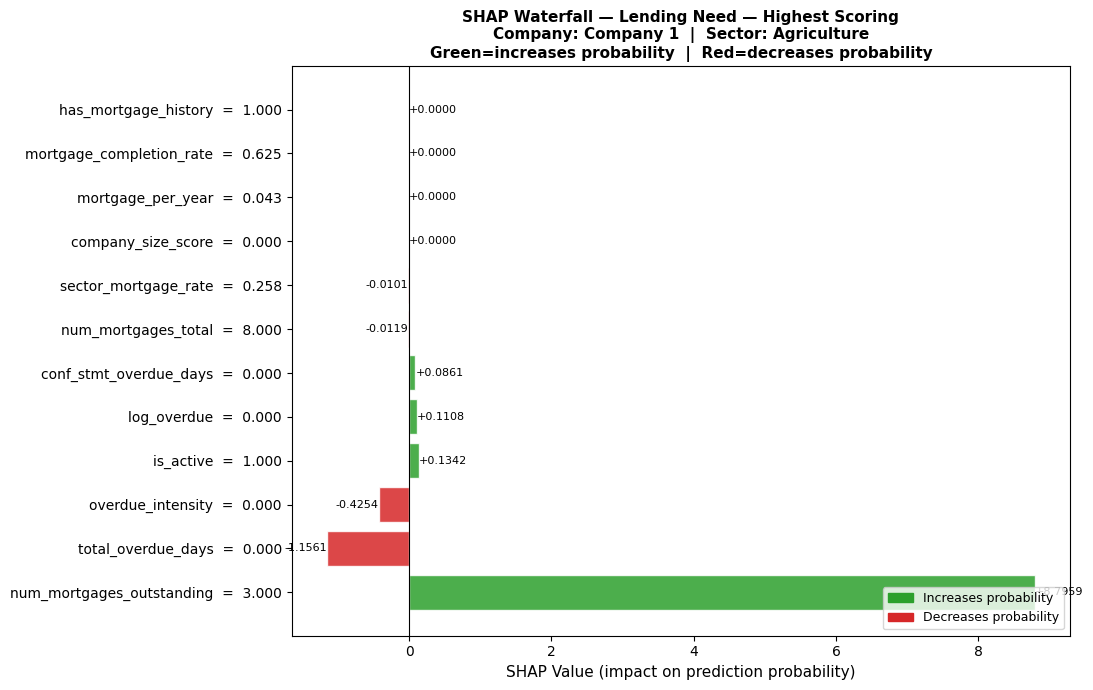

Saved: output/shap_waterfall_lending_top.png

Borderline growth: idx=13 score=0.4953


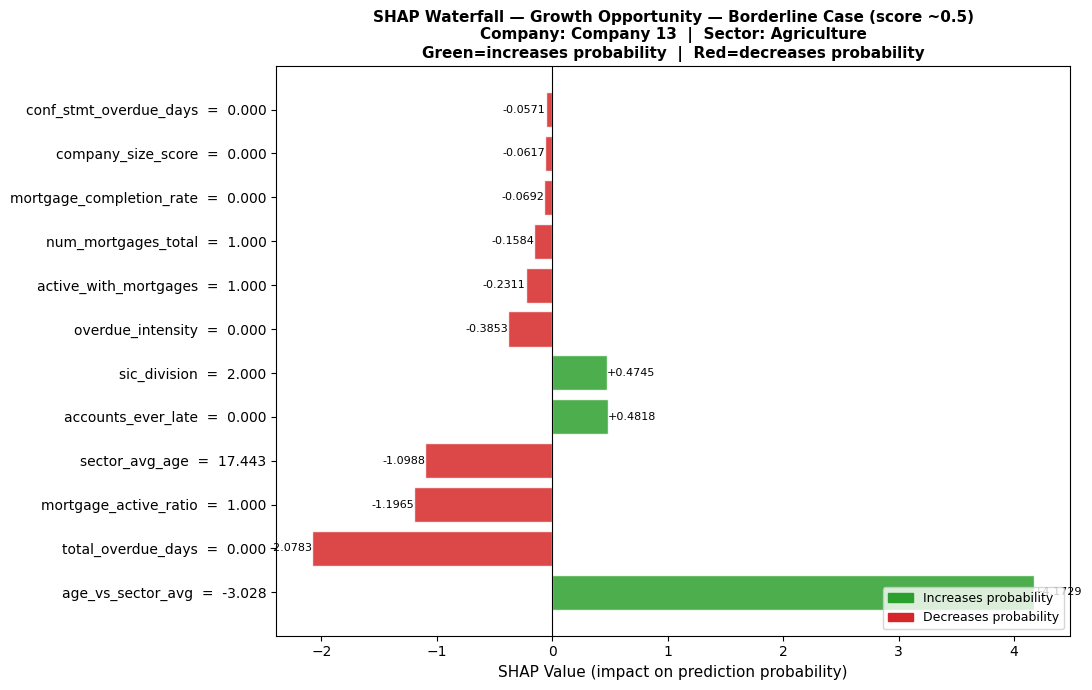

Saved: output/shap_waterfall_growth_borderline.png


In [11]:
def plot_waterfall(shap_vals, X_df, feats, sample_df, idx, label_name, filename, top_n=12):
    shap_row = shap_vals[idx]
    feat_vals = X_df.iloc[idx]
    contrib = pd.DataFrame({'feature':feats,'shap_value':shap_row,'feature_value':feat_vals.values})\
              .sort_values('shap_value', key=abs, ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(11, 7))
    colors = [COLOURS['growth'] if v>0 else COLOURS['risk'] for v in contrib['shap_value']]
    labels_y = [f"{r['feature']}  =  {r['feature_value']:.3f}" for _,r in contrib.iterrows()]
    bars = ax.barh(labels_y, contrib['shap_value'], color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP Value (impact on prediction probability)', fontsize=11)

    sector = sample_df.iloc[idx].get('bcb_sector','Unknown') if 'bcb_sector' in sample_df.columns else 'Unknown'
    company = sample_df.iloc[idx].get('CompanyName', f'Company {idx}') if 'CompanyName' in sample_df.columns else f'Company {idx}'
    ax.set_title(f'SHAP Waterfall — {label_name}\nCompany: {company}  |  Sector: {sector}\nGreen=increases probability  |  Red=decreases probability', fontsize=11, fontweight='bold')

    for bar, val in zip(bars, contrib['shap_value']):
        xpos = bar.get_width() + (0.0005 if val>=0 else -0.0005)
        ax.text(xpos, bar.get_y()+bar.get_height()/2, f'{val:+.4f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)

    pos_p = mpatches.Patch(color=COLOURS['growth'], label='Increases probability')
    neg_p = mpatches.Patch(color=COLOURS['risk'],   label='Decreases probability')
    ax.legend(handles=[pos_p,neg_p], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {filename}')

prob_growth  = xgb_growth.predict_proba(X_growth)[:,1]
prob_risk    = xgb_risk.predict_proba(X_risk)[:,1]
prob_lending = xgb_lending.predict_proba(X_lending)[:,1]

idx = int(np.argmax(prob_growth))
print(f'\nTop growth: idx={idx} score={prob_growth[idx]:.4f}')
plot_waterfall(shap_values_growth, X_growth, features_growth, sample, idx, 'Growth Opportunity — Highest Scoring', 'output/shap_waterfall_growth_top.png')

idx = int(np.argmax(prob_risk))
print(f'\nTop risk: idx={idx} score={prob_risk[idx]:.4f}')
plot_waterfall(shap_values_risk, X_risk, features_risk, sample, idx, 'Risk Signal — Highest Scoring', 'output/shap_waterfall_risk_top.png')

idx = int(np.argmax(prob_lending))
print(f'\nTop lending: idx={idx} score={prob_lending[idx]:.4f}')
plot_waterfall(shap_values_lending, X_lending, features_lending, sample, idx, 'Lending Need — Highest Scoring', 'output/shap_waterfall_lending_top.png')

idx = int(np.argmin(np.abs(prob_growth - 0.5)))
print(f'\nBorderline growth: idx={idx} score={prob_growth[idx]:.4f}')
plot_waterfall(shap_values_growth, X_growth, features_growth, sample, idx, 'Growth Opportunity — Borderline Case (score ~0.5)', 'output/shap_waterfall_growth_borderline.png')

## Section 12 — Leakage Diagnostic

If one feature dominates >60% of total SHAP importance, the model likely learned
the label construction formula rather than genuine business patterns.

Recall from EDA: risk_signal corr with accounts_ever_late = +0.97 (excluded)
                 lending_need corr with has_active_mortgages = +0.96 (excluded)

The perfect F1=1.000 scores on lending and risk models warrant this check.

LEAKAGE DIAGNOSTIC — SHAP DOMINANCE CHECK

GROWTH OPPORTUNITY:
  Top feature:       age_vs_sector_avg
  Top feature share: 48.8%  [OK]
  Top 3 share:       75.8%

RISK SIGNAL:
  Top feature:       log_overdue
  Top feature share: 42.7%  [OK]
  Top 3 share:       92.5%

LENDING NEED:
  Top feature:       num_mortgages_outstanding
  Top feature share: 85.4%  [POSSIBLE LEAKAGE]
  Top 3 share:       95.5%

Thresholds: <40% healthy | 40-60% moderate | >60% flag


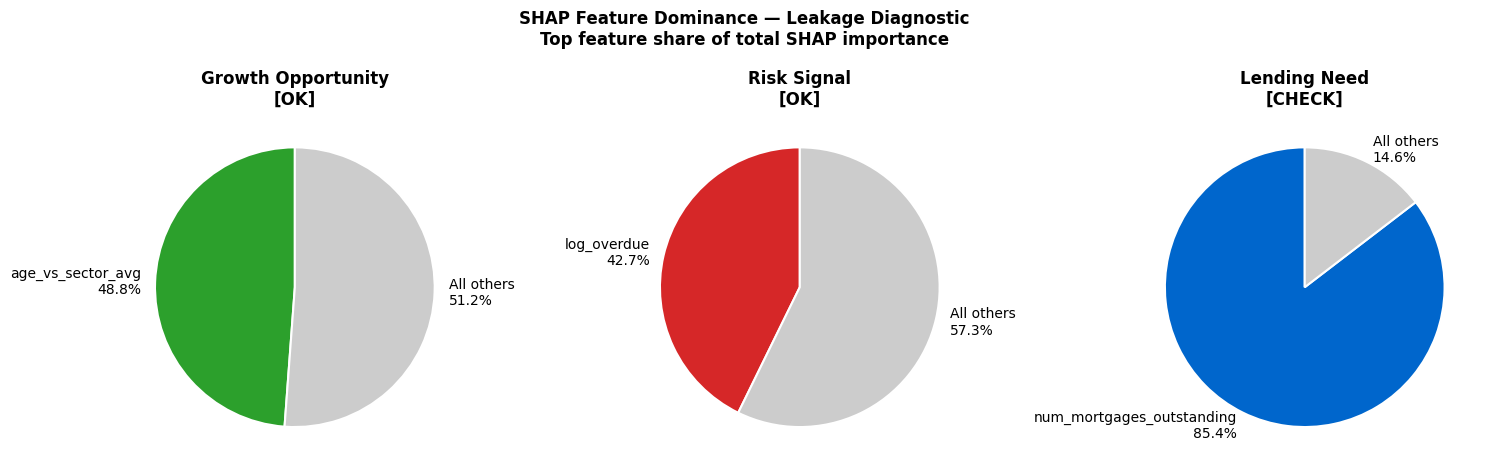

Saved: output/shap_leakage_diagnostic.png


In [12]:
print('='*62)
print('LEAKAGE DIAGNOSTIC — SHAP DOMINANCE CHECK')
print('='*62)

def dominance_check(mean_abs, feats, lbl):
    total = mean_abs.sum()
    idx = int(np.argmax(mean_abs))
    top_pct = mean_abs[idx]/total*100
    top3_pct = np.sort(mean_abs)[::-1][:3].sum()/total*100
    flag = 'POSSIBLE LEAKAGE' if top_pct>60 else 'OK'
    print(f'\n{lbl}:')
    print(f'  Top feature:       {feats[idx]}')
    print(f'  Top feature share: {top_pct:.1f}%  [{flag}]')
    print(f'  Top 3 share:       {top3_pct:.1f}%')
    return top_pct, feats[idx]

g_dom,g_top = dominance_check(np.abs(shap_values_growth).mean(axis=0),  features_growth,  'GROWTH OPPORTUNITY')
r_dom,r_top = dominance_check(np.abs(shap_values_risk).mean(axis=0),    features_risk,    'RISK SIGNAL')
l_dom,l_top = dominance_check(np.abs(shap_values_lending).mean(axis=0), features_lending, 'LENDING NEED')

print('\nThresholds: <40% healthy | 40-60% moderate | >60% flag')

fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('SHAP Feature Dominance — Leakage Diagnostic\nTop feature share of total SHAP importance', fontsize=12, fontweight='bold')
for ax,dom,top_feat,label,colour in zip(axes,[g_dom,r_dom,l_dom],[g_top,r_top,l_top],['Growth Opportunity','Risk Signal','Lending Need'],[COLOURS['growth'],COLOURS['risk'],COLOURS['lending']]):
    rest=100-dom
    ax.pie([dom,rest],labels=[f'{top_feat}\n{dom:.1f}%',f'All others\n{rest:.1f}%'],colors=[colour,'#cccccc'],startangle=90,wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(f'{label}\n[{"CHECK" if dom>60 else "OK"}]', fontweight='bold')
plt.tight_layout()
plt.savefig('output/shap_leakage_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: output/shap_leakage_diagnostic.png')

## Section 13 — Business Narrative Summary

Technical SHAP findings translated into plain English for the dissertation and Lloyds relationship managers.

In [13]:
def top3(shap_vals, feats):
    m = np.abs(shap_vals).mean(axis=0)
    return [(feats[i], round(float(m[i]),4)) for i in np.argsort(m)[::-1][:3]]

g3=top3(shap_values_growth,features_growth)
r3=top3(shap_values_risk,features_risk)
l3=top3(shap_values_lending,features_lending)

print('='*65)
print('SHAP EXPLAINABILITY — BUSINESS NARRATIVE')
print('='*65)
print(f"""
GROWTH OPPORTUNITY
  Top drivers: {g3[0][0]} ({g3[0][1]}), {g3[1][0]} ({g3[1][1]}), {g3[2][0]} ({g3[2][1]})
  The model identifies growth prospects through company maturity and compliance signals.
  Young companies with clean filing histories receive the highest growth scores.
  Lloyds action: prioritise top decile of growth_prob, especially Real Estate (62.9%)
  and Healthcare (60.2%). Use SHAP waterfall explanations as RM talking points.

RISK SIGNAL
  Top drivers: {r3[0][0]} ({r3[0][1]}), {r3[1][0]} ({r3[1][1]}), {r3[2][0]} ({r3[2][1]})
  Driven by compliance failure signals — overdue intensity is key (overdue days / company age).
  Chronic late filers show operational stress, not just a one-off delay.
  Note: ROC-AUC 1.000 — check leakage diagnostic. Agriculture (10.2%) needs closest monitoring.
  Lloyds action: risk-flagged companies trigger support teams, not product sales.

LENDING NEED
  Top drivers: {l3[0][0]} ({l3[0][1]}), {l3[1][0]} ({l3[1][1]}), {l3[2][0]} ({l3[2][1]})
  Mortgage history and company maturity dominate. Prior borrowers borrow again.
  Completion rate (% repaid) shows credit quality alongside need.
  Note: F1 1.000 — check leakage diagnostic for feature dominance.
  Lloyds action: Real Estate (37.4%) for commercial mortgage, Agriculture (25.8%) for working capital.
""")

print('='*65)
print('ALL SHAP OUTPUT FILES (output/ folder):')
print('='*65)
for f in ['shap_bar_growth.png','shap_bar_risk.png','shap_bar_lending.png','shap_beeswarm_growth.png','shap_beeswarm_risk.png','shap_beeswarm_lending.png','shap_cross_label_comparison.png','shap_cross_label_importance.csv','shap_waterfall_growth_top.png','shap_waterfall_risk_top.png','shap_waterfall_lending_top.png','shap_waterfall_growth_borderline.png','shap_leakage_diagnostic.png']:
    print(f'  {f}')

SHAP EXPLAINABILITY — BUSINESS NARRATIVE

GROWTH OPPORTUNITY
  Top drivers: age_vs_sector_avg (5.0516), total_overdue_days (1.6843), sector_avg_age (1.1074)
  The model identifies growth prospects through company maturity and compliance signals.
  Young companies with clean filing histories receive the highest growth scores.
  Lloyds action: prioritise top decile of growth_prob, especially Real Estate (62.9%)
  and Healthcare (60.2%). Use SHAP waterfall explanations as RM talking points.

RISK SIGNAL
  Top drivers: log_overdue (4.7666), log_company_age (3.0233), overdue_intensity (2.5264)
  Driven by compliance failure signals — overdue intensity is key (overdue days / company age).
  Chronic late filers show operational stress, not just a one-off delay.
  Note: ROC-AUC 1.000 — check leakage diagnostic. Agriculture (10.2%) needs closest monitoring.
  Lloyds action: risk-flagged companies trigger support teams, not product sales.

LENDING NEED
  Top drivers: num_mortgages_outstanding (9